# Introduction to Statistical methods: Maximum Likelihood Estimation

In [ ]:
# Importing modules
import numpy as np; 
import matplotlib.pyplot as plt; 
from scipy.signal import find_peaks; 
from scipy.optimize import minimize; 

# np.random.seed(42) # In order to ensure reproducibility. You can use different seed values.

In [2]:
# Defining methods
hermitian = lambda array: np.conj(array).T; 


def steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  omega = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]); 
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@omega); 


def d_steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  a = steering_vector(sensor_pos, ang_elev, ang_azim, wavelen); 
  d_omega = np.array([[np.cos(ang_elev)*np.cos(ang_azim)],
                      [np.cos(ang_elev)*np.sin(ang_azim)],
                      [-np.sin(ang_elev)]]); 
  return -1j*2*np.pi/wavelen * a * sensor_pos.T@d_omega; 


def generate_pos_1d_ula(N: int, d: float, axis=(1.,0.,0.), x_init=(0.,0.,0.)) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def calculate_crb(sensor_pos: np.ndarray, N: int, T: int, wl: float, angs_elev: np.ndarray, snr_db: float, S_db: list) -> np.ndarray:
  noise_pow = 10**(-snr_db/10); 
  sig_pow = [10**(s_db)/10 for s_db in S_db]; 
  R_ss = np.diag(np.array(sig_pow)); 

  K = angs_elev.shape[0]; 

  # Steering matrix (A_mat) Derivative matrix (D_mat) of steering vectors w.r.t angles (in degrees)
  A_mat = np.zeros((N, K), dtype=complex); 
  D_mat = np.zeros((N, K), dtype=complex); 

  for i, theta in enumerate(angs_elev):
    A_mat[:,i] = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 
    D_mat[:,i] = d_steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 

  Rxx_true = A_mat@R_ss@A_mat.conj().T + noise_pow*np.eye(N); 
  Rxx_inv = np.linalg.inv(Rxx_true); 

  P_A_perp = np.eye(N) - A_mat@np.linalg.inv(A_mat.conj().T@A_mat)@A_mat.conj().T; # Projection matrix onto the noise subspace

  # The Fisher Information Matrix components
  term1 = D_mat.conj().T @ P_A_perp @ D_mat; 
  term2 = (R_ss @ A_mat.conj().T @ Rxx_inv @ A_mat @ R_ss).T; 

  FIM = (2*T/noise_pow) * np.real(term1*term2); 

  return np.linalg.inv(FIM); 


def generate_random_targets(ang_min: float, ang_max: float, ang_dist: float, K: int) -> np.ndarray:
  while True:
    angs = np.random.uniform(ang_min, ang_max, K); 
    angs_sort = np.sort(angs); 
    for i in range(K-1):  # break for if is not valid
      is_valid = np.abs(angs_sort[i+1] - angs_sort[i]) >= ang_dist; 
      if not is_valid:
        break; 
    if is_valid: break;   # break while if is valid
  return angs; 


def doa_est_music(theta_scan: np.ndarray, sensor_pos:  np.ndarray, R_xx: np.ndarray, wl: float, K: int):
  _, e_vec = np.linalg.eigh(R_xx); 
  Un = e_vec[:, :-K]; 

  P_music = np.zeros(len(theta_scan), dtype=np.float64); 

  for i, theta in enumerate(theta_scan):
      a_theta = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
      denominator = np.abs(a_theta.conj().T @ Un @ Un.conj().T @ a_theta); 
      P_music[i] = 1 / np.squeeze(denominator); 

  return P_music; 

In [3]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f_c = 5*1e9;    # Narrowband signal frequency (Hz)
f_s = 100*1e9;  # Receiver sampling frequency (Hz)
wl = c/f_c;     # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 1000;       # Number of snapshots
K = 5;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)
snr_db = 10.0;  # Signal-to-Noise Ratio (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -60;  # Minimum elevation angle (deg)
ang_max = 60;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 0.1   # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position
theta_scan = np.arange(-90,90+ang_res,ang_res);                         # Angle scan
true_angles = generate_random_targets(ang_min, ang_max, ang_dist, K);   # Target elevation angles

for k in range(K):
  print(f"Target {k} True Angle: {true_angles[k]:.3f}°"); 

Target 0 True Angle: -31.495°
Target 1 True Angle: 57.626°
Target 2 True Angle: -6.105°
Target 3 True Angle: 35.354°
Target 4 True Angle: 10.111°


In [4]:
# Data Generation
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in true_angles]); # Array Steering Matrix
S_amp = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]); 
S = S_amp @ (np.random.randn(K, T) + 1j*np.random.randn(K, T))/np.sqrt(2); # Target Signals: Uncorrelated Gaussian (variance = 1.0)

# Noise: Spatially white complex Gaussian noise
noise_pow = 10**(-snr_db/10); 
Noise = np.sqrt(noise_pow) * (np.random.randn(N, T) + 1j*np.random.randn(N, T))/np.sqrt(2); 

# Received Signal at the Array
X = A @ S + Noise; 
R_xx = (X @ hermitian(X))/T;      # Sample covariance matrix

The optimized cost value is mathematically equivalent to the log-det of $\mathbf{R}({\theta})$ when the trace term is fully concentrated.

In [ ]:
def sml_cost_function(theta: np.ndarray, R_xx: np.ndarray, N: int, K: int, wl: float):
    """
    Evaluates the concentrated Stochastic Maximum Likelihood cost function.
    """
    # Ensure theta shape is correct for matrix construction
    theta = np.atleast_1d(theta); 
    # m = np.arange(N).reshape(-1, 1); 
    
    # Ateering matrix for candidate angles and its pseudo-inverse
    A = np.column_stack([steering_vector(sensor_pos, theta, 0, wl) for theta in theta]); 
    A_pinv = np.linalg.pinv(A); 
    
    P_A_perp = np.eye(N) - A @ A_pinv;      # Projection matrix onto the noise subspace
    
    # Concentrated estimation of noise variance
    sig_est = np.real(np.trace(P_A_perp @ R_xx)) / (N - K); 
    sig_est = max(sig_est, 1e-8);           # Ensure noise variance remains strictly positive to avoid log/inversion stability issues
    
    # Concentrated estimation of source covariance matrix (P)
    P_hat = A_pinv @ (R_xx - sig_est * np.eye(N)) @ A_pinv.conjugate().T; 
    
    # Reconstructed parametric covariance matrix R(theta)
    R_theta = A @ P_hat @ A.conjugate().T + sig_est * np.eye(N); 
    
    # Computes log-determinant safely using sign and natural log
    sign, logdet = np.linalg.slogdet(R_theta); 
    if sign <= 0:
        raise ValueError("The reconstructed covariance matrix R(theta) is not positive definite."); 
    
    return logdet; 

In [ ]:
# The coarse peak outputs from your MUSIC is used as initial estimations.
P_music = doa_est_music(theta_scan, sensor_pos, R_xx, wl, K); 
P_music_dB = 10 * np.log10(P_music / np.max(P_music)); 
idx, _ = find_peaks(P_music_dB, height=-5); 
initial_guess_deg = np.sort(theta_scan[idx]); 
#initial_guess_deg = initial_guess_deg + np.random.randn(len(initial_guess_deg));  # Let's intentionally bias the initial guess to test the solver's convergence performance.
initial_guess_rad = np.radians(initial_guess_deg); 

print(f"True Angles (deg): {np.round(np.sort(true_angles), 3)}"); 
print(f"Initial Guess supplied to Optimizer (deg): {initial_guess_deg}\n"); 

# Running multi-dimensional minimization using Nelder-Mead simplex algorithm
result = minimize(
    fun=sml_cost_function,
    x0=initial_guess_rad,
    args=(R_xx, N, K, wl),
    method='Nelder-Mead',
    options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 1000}
); 

estimated_angles_deg = np.degrees(result.x); 
# Sort results for visual alignment with true values
estimated_angles_deg.sort(); 

print("--- Optimization Results ---"); 
if result.success:
  print(f"Convergence is Successful!"); 
  print(f"Stochastic ML Estimated Angles (deg): {np.round(estimated_angles_deg, 3)}"); 
  print(f"Absolute Estimation Error (deg): {np.round(np.abs(np.sort(true_angles) - estimated_angles_deg), 3)}"); 
else:
  print(f"Convergence Failed!"); 

True Angles (deg): [-31.495  -6.105  10.111  35.354  57.626]
Initial Guess supplied to Optimizer (deg): [-31.5  -6.1  10.1  35.3  57.6]

--- Optimization Results ---
Convergence is Successful!
SML Estimated Angles (deg): [-31.488  -6.091  10.108  35.35   57.621]
Absolute Estimation Error (deg): [0.008 0.014 0.003 0.004 0.005]


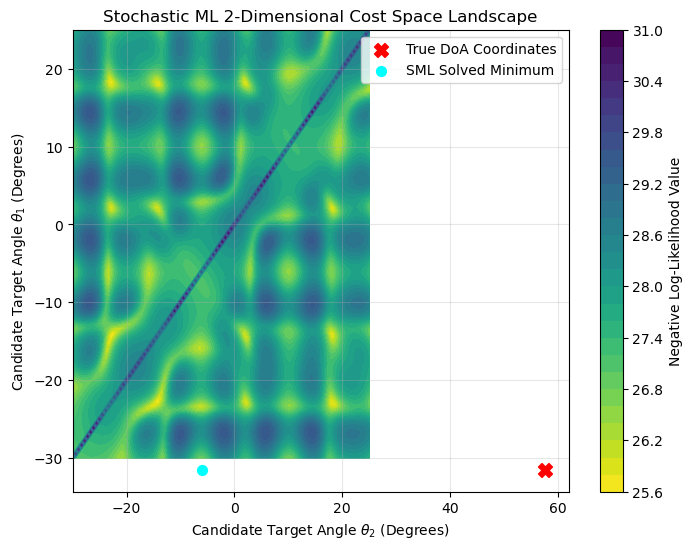

In [8]:
# Generate a grid around the true values to plot the likelihood surface
angle_axis = np.linspace(-30, 25, 100); 
angle_grid_rad = np.radians(angle_axis); 
z_surface = np.zeros((len(angle_axis), len(angle_axis))); 

for i, t1 in enumerate(angle_grid_rad):
  for j, t2 in enumerate(angle_grid_rad):
    z_surface[i, j] = sml_cost_function(np.array([t1, t2]), R_xx, N, K, wl); 

# Plotting the cost surface map
plt.figure(figsize=(8, 6)); 
contour = plt.contourf(angle_axis, angle_axis, z_surface, levels=30, cmap='viridis_r'); 
plt.colorbar(contour, label='Negative Log-Likelihood Value'); 

# Highlight Key Identifiers
plt.scatter(true_angles[1], true_angles[0], color='red', marker='X', s=100, label="True DoA Coordinates"); 
plt.scatter(estimated_angles_deg[1], estimated_angles_deg[0], color='cyan', marker='o', s=50, label="SML Solved Minimum"); 

plt.title("Stochastic ML 2-Dimensional Cost Space Landscape"); 
plt.xlabel("Candidate Target Angle $\\theta_2$ (Degrees)"); 
plt.ylabel("Candidate Target Angle $\\theta_1$ (Degrees)"); 
plt.legend(); 
plt.grid(True, alpha=0.3); 
plt.show(); 